# SMILES → Odor Mapping for M2OR Ligands (Pyrfume Pipeline)

### Annotating M2OR odorants with Leffingwell & GoodScents descriptors via the Pyrfume archives

**Objective.** For every non-mixture compound in **M2OR**, attach its perceptual odor
descriptors drawn from two **Pyrfume** archives — **Leffingwell** and **GoodScents** —
producing one row per molecule with two descriptor columns (`odors_leff`, `odors_gs`).

In [1]:
import sys
import pyrfume as pf
import pandas as pd

print("Python :", sys.version.split()[0])
print("pandas :", pd.__version__)
print("pyrfume:", getattr(pf, "__version__", "unknown"))

/home/izirdeli/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python : 3.12.4
pandas : 2.2.3
pyrfume: unknown


In [2]:
pf.list_archives()

['abraham_2012',
 'ahmed_2018',
 'arctander_1960',
 'aromadb',
 'arshamian_2022',
 'bolding_2018',
 'burton_2022',
 'bushdid_2014',
 'chae_2019',
 'dravnieks_1985',
 'embedding',
 'flavordb',
 'flavornet',
 'foodb',
 'foodcomex',
 'fragrancedb',
 'freesolve',
 'goodscents',
 'gras',
 'haddad_2008',
 'ifra_2019',
 'iurilli_2017',
 'jones_2019',
 'keller_2012',
 'keller_2016',
 'knapsack',
 'leffingwell',
 'leon',
 'ma_2012',
 'ma_2021',
 'mainland_2015',
 'manoel_2021',
 'mayhew_2022',
 'molecules',
 'mordred',
 'morgan',
 'nagappan_2021',
 'nakayama_2022',
 'nat_geo_1986',
 'nhanes_2014',
 'optical_rotation',
 'prediction_targets',
 'prestwick',
 'qian_2022',
 'ravia_2020',
 'scott_2014',
 'sharma_2021a',
 'sharma_2021b',
 'sigma_2014',
 'sisson_2024',
 'slone_2017',
 'snitz_2013',
 'snitz_2019',
 'soh_2013',
 'superscent',
 't3db',
 'tools',
 'wakayama_2019',
 'weiss_2012',
 'yu_2015']

In [3]:
mol_leff = pf.load_data('leffingwell/molecules.csv')
stim_leff = pf.load_data('leffingwell/stimuli.csv')
beh_leff  = pf.load_data('leffingwell/behavior.csv')

mol_gs = pf.load_data('goodscents/molecules.csv')
stim_gs = pf.load_data('goodscents/stimuli.csv')
beh_gs  = pf.load_data('goodscents/behavior.csv')

m2or = pd.read_csv("../Data/m2or_pairs.csv", engine='python', sep=None)

print("leffingwell behavior :", beh_leff.shape)
print("goodscents  behavior :", beh_gs.shape)
print("m2or pairs           :", m2or.shape)

leffingwell behavior : (3522, 113)
goodscents  behavior : (4626, 1)
m2or pairs           : (53444, 14)


In [4]:
m2or_compounds = m2or[m2or["Mixture"] != "mixture"]
# CID is carried through so the alternative join keys can be tested later on
m2or_compounds = m2or_compounds[["Molecule Name", "CID", "InChIKey", "SMILES"]].drop_duplicates()
m2or_compounds = m2or_compounds.drop_duplicates(subset=["SMILES"], keep="first")

print(m2or_compounds["Molecule Name"].nunique())
print(m2or_compounds["InChIKey"].nunique())
print(m2or_compounds["SMILES"].nunique())

751
753
754


In [5]:
#rows that have identical "Molecule Name"
m2or_compounds[m2or_compounds.duplicated(subset=["Molecule Name"], keep=False)].sort_values(by=["Molecule Name"])

,Molecule Name,CID,InChIKey,SMILES
417,2-decenal,5283345.0,MMFCJPPRCYDLLZ-CMDGGOBGSA-N,CCCCCCC/C=C/C=O
38725,2-decenal,19801.0,MMFCJPPRCYDLLZ-UHFFFAOYSA-N,CCCCCCCC=CC=O
442,isobornyl acetate,247573.0,KGEKLUUHTZCSIP-JFGNBEQYSA-N,CC(=O)O[C@H]1C[C@H]2CC[C@]1(C2(C)C)C
34405,isobornyl acetate,637531.0,KGEKLUUHTZCSIP-FOGDFJRCSA-N,CC(=O)O[C@@H]1C[C@H]2CC[C@@]1(C2(C)C)C
38731,isobornyl acetate,6448.0,KGEKLUUHTZCSIP-UHFFFAOYSA-N,CC(=O)OC1CC2CCC1(C2(C)C)C


In [6]:
m2or_compounds[m2or_compounds["SMILES"].notna() & m2or_compounds["InChIKey"].isna()]

,Molecule Name,CID,InChIKey,SMILES
24593,3-Mercapto-2-methyloctan-1-ol,NaN,NaN,CCCCCC(C(C)CO)S


## Pyrfume Datasets

In [7]:
mol_leff

,MolecularWeight,IsomericSMILES,IUPACName,name
CID,,,,
-955348933095,240.387,CCCCC=COC(=O)CCCCCCCC,NaN,Hexenyl nonanoate
-923209957509,196.290,CC(=O)OCC1C=CC(C(C)C)CC1,NaN,Tetrahydrocuminyl acetate
-874408321546,244.331,CCCCCCCCC(OC(C)=O)C(=O)OC,NaN,Methyl acetoxydecanoate
-873963935677,198.306,CCCCC=COC(=O)C(C)CCC,NaN,Hexenyl methylvalerate
-862841422647,148.271,CCCC(S)COCC,NaN,Ethoxymethylbutanethiol
...,...,...,...,...
154241350,222.400,CCC1CSSSC1(CC)CC,"4,4,5-triethyltrithiane","4,4,5-triethyltrithiane"
155323379,126.300,CC(S)SS,1-(disulfanyl)ethanethiol,schembl22694105
158699780,174.310,CCC(C)C(=S)OCC(C)C,O-(2-methylpropyl) 2-methylbutanethioate,O-(2-methylpropyl) 2-methylbutanethioate


In [8]:
stim_leff

,CID,MolecularWeight,IsomericSMILES,IUPACName,name,cas
Stimulus,,,,,,
-955348933095,-955348933095,240.387,CCCCC=COC(=O)CCCCCCCC,NaN,Hexenyl nonanoate,88191-46-2
-923209957509,-923209957509,196.290,CC(=O)OCC1C=CC(C(C)C)CC1,NaN,Tetrahydrocuminyl acetate,NaN
-874408321546,-874408321546,244.331,CCCCCCCCC(OC(C)=O)C(=O)OC,NaN,Methyl acetoxydecanoate,NaN
-873963935677,-873963935677,198.306,CCCCC=COC(=O)C(C)CCC,NaN,Hexenyl methylvalerate,NaN
-862841422647,-862841422647,148.271,CCCC(S)COCC,NaN,Ethoxymethylbutanethiol,NaN
...,...,...,...,...,...,...
154241350,154241350,222.400,CCC1CSSSC1(CC)CC,"4,4,5-triethyltrithiane","4,4,5-triethyltrithiane",53897-58-5
155323379,155323379,126.300,CC(S)SS,1-(disulfanyl)ethanethiol,schembl22694105,7529-06-8
158699780,158699780,174.310,CCC(C)C(=S)OCC(C)C,O-(2-methylpropyl) 2-methylbutanethioate,O-(2-methylpropyl) 2-methylbutanethioate,127931-21-9


In [9]:
beh_leff

,alcoholic,aldehydic,alliaceous,almond,animal,anisic,apple,apricot,aromatic,balsamic,...,tobacco,tomato,tropical,vanilla,vegetable,violet,warm,waxy,winey,woody
Stimulus,,,,,,,,,,,,,,,,,,,,,
-955348933095,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
-923209957509,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
-874408321546,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
-873963935677,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
-862841422647,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154241350,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
155323379,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
158699780,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [10]:
(beh_leff == 0).all().any()

False

In [11]:
(beh_leff == 0).all(axis=1).any()

False

In [12]:
odor_terms = beh_leff.apply(
    lambda row: ", ".join(beh_leff.columns[row == 1]),
    axis=1,
)

leffingwell = stim_leff[["IsomericSMILES", "name"]].copy()
leffingwell["odors_leff"] = odor_terms

leffingwell = leffingwell.reset_index()[["Stimulus", "IsomericSMILES", "name", "odors_leff"]]

leffingwell

,Stimulus,IsomericSMILES,name,odors_leff
0,-955348933095,CCCCC=COC(=O)CCCCCCCC,Hexenyl nonanoate,"fruity, green, herbal, oily, waxy"
1,-923209957509,CC(=O)OCC1C=CC(C(C)C)CC1,Tetrahydrocuminyl acetate,"fruity, herbal, spicy, woody"
2,-874408321546,CCCCCCCCC(OC(C)=O)C(=O)OC,Methyl acetoxydecanoate,"apricot, buttery, peach"
3,-873963935677,CCCCC=COC(=O)C(C)CCC,Hexenyl methylvalerate,"apple, fruity, green, tropical"
4,-862841422647,CCCC(S)COCC,Ethoxymethylbutanethiol,catty
...,...,...,...,...
3517,154241350,CCC1CSSSC1(CC)CC,"4,4,5-triethyltrithiane","alliaceous, green, onion, savory"
3518,155323379,CC(S)SS,schembl22694105,"alliaceous, roasted, savory, sulfurous"
3519,158699780,CCC(C)C(=S)OCC(C)C,O-(2-methylpropyl) 2-methylbutanethioate,"cheesy, creamy, fruity, ripe, strawberry, sulf..."
3520,161504856,CCCCCCCC=COC(=O)CCC,non-1-enyl butanoate,"fruity, green, melon, tropical, waxy"


In [13]:
leffingwell["odors_leff"].isna().sum()

0

In [14]:
mol_gs

,MolecularWeight,IsomericSMILES,IUPACName,name
CID,,,,
4,75.11,CC(CN)O,1-aminopropan-2-ol,1-aminopropan-2-ol
49,116.11,CC(C)C(=O)C(=O)O,3-methyl-2-oxobutanoic acid,3-methyl-2-oxobutanoic acid
51,146.10,C(CC(=O)O)C(=O)C(=O)O,2-oxopentanedioic acid,2-ketoglutaric acid
58,102.09,CCC(=O)C(=O)O,2-oxobutanoic acid,2-oxobutanoic acid
70,130.14,CC(C)CC(=O)C(=O)O,4-methyl-2-oxopentanoic acid,4-methyl-2-oxopentanoic acid
...,...,...,...,...
135565141,386.27,C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H...,"calcium;[(2R,3S,4R,5R)-3,4-dihydroxy-5-(6-oxo-...",calcium 5'-inosinate
135565649,401.28,C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)COP(=O...,"calcium;[(2R,3S,4R,5R)-5-(2-amino-6-oxo-1H-pur...",calcium 5'-guanylate
135565913,439.40,C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)COP(=O...,"dipotassium;[(2R,3S,4R,5R)-5-(2-amino-6-oxo-1H...",dipotassium 5'-guanylate


In [15]:
stim_gs

,TGSC ID,CID,Concentration %,Solvent
Stimulus,,,,
100-06-1,1000111,7476,100.0,NaN
100-09-4,1031871,7478,10.0,dipropylene glycol
100-42-5,1009281,7501,0.1,triacetin
100-51-6,1001651,244,100.0,NaN
100-52-7,1001491,240,10.0,dipropylene glycol
...,...,...,...,...
NF0802,1020461,11564539,NaN,NaN
NF0803,1027261,46195361,1.0,dipropylene glycol
NF0804,1028151,46195364,0.1,propylene glycol


In [16]:
beh_gs

,Descriptors
Stimulus,
100-06-1,sweet;vanilla;cherry maraschino cherry;powdery...
100-09-4,phenolic;animal;fecal;medicinal
100-42-5,sweet;plastic;floral;balsamic
100-51-6,sweet;floral;rose;fruity;phenolic;balsamic;che...
100-52-7,sweet;cherry;cherry maraschino cherry;nutty;fr...
...,...
NF0802,flowers;orange
NF0803,vegetable;floral;fruity;apricot;green;tropical...
NF0804,spicy;leafy;peppery;banana;fruity;oily;cantalo...


In [17]:
beh_gs["Descriptors"].isna().sum()

4

In [18]:
#print the exact rows where Descriptors is NaN
beh_gs[beh_gs["Descriptors"].isna()]

,Descriptors
Stimulus,
1523-19-9,NaN
53584-56-8,NaN
6698-82-0,NaN
78183-56-9,NaN


In [19]:
odors_gs = beh_gs["Descriptors"].str.replace(";", ", ", regex=False)

goodscents = stim_gs[["CID"]].merge(
    mol_gs[["IsomericSMILES", "name"]],
    left_on="CID",
    right_index=True,
    how="left",
)
goodscents["odors_gs"] = odors_gs
goodscents = goodscents.reset_index()[["Stimulus", "IsomericSMILES", "name", "odors_gs"]]

goodscents

,Stimulus,IsomericSMILES,name,odors_gs
0,100-06-1,CC(=O)C1=CC=C(C=C1)OC,4'-methoxyacetophenone,"sweet, vanilla, cherry maraschino cherry, powd..."
1,100-09-4,COC1=CC=C(C=C1)C(=O)O,4-methoxybenzoic acid,"phenolic, animal, fecal, medicinal"
2,100-42-5,C=CC1=CC=CC=C1,styrene,"sweet, plastic, floral, balsamic"
3,100-51-6,C1=CC=C(C=C1)CO,benzyl alcohol,"sweet, floral, rose, fruity, phenolic, balsami..."
4,100-52-7,C1=CC=C(C=C1)C=O,benzaldehyde,"sweet, cherry, cherry maraschino cherry, nutty..."
...,...,...,...,...
4621,NF0802,CCCCCCCC(=C)C(C)O,3-methylidenedecan-2-ol,"flowers, orange"
4622,NF0803,CCC1OCCC(S1)C,schembl2678282,"vegetable, floral, fruity, apricot, green, tro..."
4623,NF0804,CCCCC1OCCC(S1)C,schembl2676606,"spicy, leafy, peppery, banana, fruity, oily, c..."
4624,NF0824,CC[C@@H](C)CCC=O,(r)-4-methylhexanal,"flowery, fresh, green, warm"


In [20]:
goodscents["odors_gs"].isna().sum()

4

### Merge Leffingwell & Goodscents

In [21]:
# Helper function: prevents descriptor loss. It merges comma-separated tag strings
# across rows, de-duplicating case-insensitively while preserving first-seen order.

def union_tags(series) -> str:
    """Union comma-separated descriptor strings across rows (order-preserving, case-insensitive)."""
    seen, out = set(), []
    for value in series.dropna():
        for tag in (t.strip() for t in str(value).split(",")):
            if tag and tag.lower() not in seen:
                seen.add(tag.lower())
                out.append(tag)
    return ", ".join(out)

In [22]:
# First, collapse each source to one row per molecule
leffingwell = (
    leffingwell.groupby("IsomericSMILES", as_index=False)
    .agg(name=("name", "first"),
         Stimulus_leff=("Stimulus", "first"),
         odors_leff=("odors_leff", union_tags))
)
goodscents = (
    goodscents.groupby("IsomericSMILES", as_index=False)
    .agg(name=("name", "first"),
         Stimulus_gs=("Stimulus", "first"),
         odors_gs=("odors_gs", union_tags))
)

# empty union -> missing, so notna()-based coverage counts are meaningful
leffingwell["odors_leff"] = leffingwell["odors_leff"].replace("", pd.NA)
goodscents["odors_gs"]    = goodscents["odors_gs"].replace("", pd.NA)

print("Leffingwell unique molecules :", len(leffingwell))
print("GoodScents  unique molecules :", len(goodscents))

Leffingwell unique molecules : 3522
GoodScents  unique molecules : 4565


In [23]:
# IsomericSMILES is the only common key across the two datasets:
# leffingwell uses hashed CIDs as Stimulus, goodscents uses CAS / real PubChem CIDs,
# so we align on the molecule itself. Outer join keeps every molecule from both sources.
merged = pd.merge(
    leffingwell,
    goodscents,
    on="IsomericSMILES",
    how="outer",
    suffixes=("_leff", "_gs"),
)
merged["name"] = merged["name_leff"].combine_first(merged["name_gs"])
merged = merged[
    ["IsomericSMILES", "name", "Stimulus_leff", "Stimulus_gs", "odors_leff", "odors_gs"]
]

both      = merged["odors_leff"].notna() & merged["odors_gs"].notna()
only_leff = merged["odors_leff"].notna() & merged["odors_gs"].isna()
only_gs   = merged["odors_leff"].isna()  & merged["odors_gs"].notna()
print(f"total molecules : {len(merged)}")
print(f"in both         : {both.sum()}")
print(f"only leffingwell: {only_leff.sum()}")
print(f"only goodscents : {only_gs.sum()}")

total molecules : 5862
in both         : 2225
only leffingwell: 1297
only goodscents : 2336


In [24]:
# Goal: annotate the m2or compounds with odor tags from the pyrfume datasets.
# Keep every m2or compound (left join); attach odors where the SMILES matches.
# NOTE: m2or SMILES and pyrfume IsomericSMILES come from different sources, so this is
# an exact-string match -- chemically identical molecules written differently won't match.
m2or_odors = m2or_compounds.merge(
    merged,
    left_on="SMILES",
    right_on="IsomericSMILES",
    how="left",
)

matched  = m2or_odors["IsomericSMILES"].notna()
has_leff = m2or_odors["odors_leff"].notna()
has_gs   = m2or_odors["odors_gs"].notna()
print(f"m2or compounds        : {len(m2or_odors)}")
print(f"matched to pyrfume    : {matched.sum()}")
print(f"  - has leffingwell   : {has_leff.sum()}")
print(f"  - has goodscents    : {has_gs.sum()}")
print(f"  - has both          : {(has_leff & has_gs).sum()}")
print(f"unmatched (no odors)  : {(~matched).sum()}")

m2or compounds        : 754
matched to pyrfume    : 577
  - has leffingwell   : 464
  - has goodscents    : 556
  - has both          : 443
unmatched (no odors)  : 177


In [25]:
m2or_odors

,Molecule Name,CID,InChIKey,SMILES,IsomericSMILES,name,Stimulus_leff,Stimulus_gs,odors_leff,odors_gs
0,(-)-limonene,439250.0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,CC1=CC[C@H](CC1)C(=C)C,CC1=CC[C@H](CC1)C(=C)C,(-)-limonene,439250.0,5989-54-8,"herbal, orange","peppery, herbal, terpenic, pine"
1,(+)-carvone,16724.0,ULDHMXUKGWMISQ-VIFPVBQESA-N,CC1=CC[C@@H](CC1=O)C(=C)C,CC1=CC[C@@H](CC1=O)C(=C)C,d-carvone,NaN,2244-16-8,NaN,"minty, bready, spicy, caraway"
2,(+)-menthol,165675.0,NOOLISFMXDJSKH-AEJSXWLSSA-N,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,(+)-menthol,NaN,15356-60-2,NaN,mentholic
3,1-butanol,263.0,LRHPLDYGYMQRHN-UHFFFAOYSA-N,CCCCO,CCCCO,1-butanol,263.0,71-36-3,"alcoholic, solvent, winey","sweet, fermented, oily, whiskey, fusel, balsamic"
4,1-butoxy-2-propanol,21210.0,RWNUSVWFHDHRCJ-UHFFFAOYSA-N,CCCCOCC(C)O,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
749,Ethyl 2-mercaptopropionate,519709.0,LXXNWCFBZHKFPT-UHFFFAOYSA-N,CCOC(=O)C(C)S,CCOC(=O)C(C)S,ethyl 2-mercaptopropionate,519709.0,19788-49-9,"fruity, sulfurous","meaty, sulfurous, onion green onion"
750,methyl beta-naphthyl ketone,7122.0,XSAYZAUNJMRRIR-UHFFFAOYSA-N,CC(=O)C1=CC2=CC=CC=C2C=C1,CC(=O)C1=CC2=CC=CC=C2C=C1,2-acetylnaphthalene,7122.0,93-08-3,"orange, sweet","sweet, floral, honey, powdery, neroli, orangef..."
751,(-)-geosmin,29746.0,JLPUXFOGCDVKGO-TUAOUCFPSA-N,C[C@H]1CCC[C@@]2([C@@]1(CCCC2)O)C,C[C@H]1CCC[C@@]2([C@@]1(CCCC2)O)C,geosmin,29746.0,19700-21-1,"earthy, green, herbal, musty","musty, earthy, fresh, humus"
752,Diallyldisulfid,65036.0,JDLKFOPOAOFWQN-UHFFFAOYSA-N,C=CCSS(=O)CC=C,NaN,NaN,NaN,NaN,NaN,NaN


### Descriptor normalisation

GoodScents inherits TGSC's uncontrolled vocabulary. Collapsing its qualified compounds and
spelling variants onto canonical terms before anything else keeps every downstream statistic
(co-occurrence, enrichment, the exported `Odors` column) on one coherent tag space.

In [26]:
# GoodScents descriptors come from TGSC, whose vocabulary is not controlled: qualified
# terms are stored as "<parent> <qualifier> <parent>" ("coffee roasted coffee"), and the
# same percept is spelled several ways ("jasmin"/"jasmine", "minty"/"mint"). Left raw, the
# union vocabulary is 396 terms of which ~70 are these compounds -- they fragment the tag
# space and make co-occurrence statistics unreliable. Two rules, applied in order:
#   1. an explicit alias table (auditable, edit it rather than the logic below)
#   2. a mechanical collapse for the "<parent> <qualifier> <parent>" pattern
# Anything not covered by either is left untouched.

TAG_ALIASES = {
    # -- multi-word TGSC compounds -> Leffingwell parent term --
    "orange peel": "orange", "orange rind": "orange", "lemon peel": "lemon",
    "grapefruit peel": "grapefruit", "citrus peel": "citrus", "citrus rind": "citrus",
    "melon rind": "melon", "apple skin": "apple", "apple green apple": "apple",
    "bread crust": "bread", "bread rye bread": "bread", "bread baked": "bread",
    "almond toasted almond": "almond", "almond roasted almond": "almond",
    "almond bitter almond": "almond", "hazelnut roasted hazelnut": "hazelnut",
    "peanut roasted peanut": "peanut", "barley roasted barley": "malty",
    "grain toasted grain": "malty", "corn chip": "corn", "potato chip": "potato",
    "potato raw potato": "potato", "potato baked potato": "potato",
    "chicken fat": "chicken", "chicken roasted chicken": "chicken",
    "cheesy bleu cheese": "cheesy", "cheesy roquefort cheese": "cheesy",
    "cheesy parmesan cheese": "cheesy", "cheesy limburger cheese": "cheesy",
    "chocolate dark chocolate": "chocolate", "coffee roasted coffee": "coffee",
    "meaty roasted meaty": "meaty", "beefy roasted beefy": "beefy",
    "onion green onion": "onion", "onion cooked onion": "onion",
    "pepper bell pepper": "vegetable", "pepper black pepper": "peppery",
    "pea green pea": "vegetable", "rose red rose": "rose", "rose tea rose": "rose",
    "rose dried rose": "rose", "bois de rose": "rose",
    "cherry maraschino cherry": "cherry", "currant black currant": "black currant",
    "currant bud black currant bud": "black currant",
    "licorice black licorice": "licorice", "sugar burnt sugar": "caramellic",
    "sugar brown sugar": "caramellic", "cotton candy": "candy", "bubble gum": "candy",
    "tutti frutti": "fruity", "juicy fruit": "fruity", "fruit dried fruit": "fruity",
    "fruit tropical fruit": "tropical", "passion fruit": "tropical",
    "fruit ripe fruit": "ripe", "fruit overripe fruit": "ripe",
    "woody old wood": "woody", "woody burnt wood": "woody", "fir needle": "pine",
    "violet leaf": "leafy", "new mown hay": "hay", "fresh outdoors": "fresh",
    "lily of the valley": "muguet", "cloth laundered cloth": "clean",
    "peanut butter": "peanut", "nut skin": "nutty", "nut flesh": "nutty",
    "root beer": "sassafras", "egg nog": "eggy",
    # -- single-word spelling / morphological variants --
    "jasmin": "jasmine", "minty": "mint", "flower": "floral", "flowers": "floral",
    "flowery": "floral", "blossom": "floral", "petal": "floral",
    "camphor": "camphoreous", "terpene": "terpenic", "wine": "winey", "rummy": "rum",
    "cool": "cooling", "leaf": "leafy", "fruit": "fruity", "spice": "spicy",
    "sassafrass": "sassafras",
    # -- fragments left behind by TGSC's own tokenisation --
    "bois": None, "de": None, "bud": None,
}


def normalise_tag(tag):
    """Map one raw descriptor to its canonical form; None means 'drop this tag'."""
    t = tag.strip().lower()
    if not t:
        return None
    if t in TAG_ALIASES:
        return TAG_ALIASES[t]
    parts = t.split()
    if len(parts) > 2 and parts[0] in parts[1:]:   # "<parent> <qualifier> <parent>"
        return parts[0]
    return t


def normalise_string(s):
    """Normalise a comma-separated descriptor string, de-duplicating in place."""
    if pd.isna(s):
        return pd.NA
    seen, out = set(), []
    for raw in str(s).split(","):
        t = normalise_tag(raw)
        if t and t not in seen:
            seen.add(t)
            out.append(t)
    return ", ".join(out) if out else pd.NA


def _vocab(*series):
    return {t for s in pd.concat(series).dropna() for t in str(s).split(", ")}


before = _vocab(m2or_odors["odors_leff"], m2or_odors["odors_gs"])
for frame in (merged, m2or_odors):
    for col in ("odors_leff", "odors_gs"):
        frame[col] = frame[col].map(normalise_string)
after = _vocab(m2or_odors["odors_leff"], m2or_odors["odors_gs"])

print(f"vocabulary on the M2OR subset: {len(before)} raw -> {len(after)} normalised")
print("multi-word terms remaining :", sorted(t for t in after if " " in t))

vocabulary on the M2OR subset: 396 raw -> 311 normalised
multi-word terms remaining : ['black currant']


### Export — `odor_datasets/inchi_odors_smiles.csv`

The artefact the downstream analyses consume: one row per non-mixture M2OR compound, the
union of both sources in `Odors`, each source kept separately for provenance, `coverage`
recording which sources describe it and `match_type` how it was matched.

In [27]:
from pathlib import Path
import numpy as np
from rdkit import Chem, RDLogger
RDLogger.DisableLog("rdApp.*")

OUT_CSV = Path("odor_datasets/inchi_odors_smiles.csv")

# M2OR and Pyrfume both store PubChem-canonical isomeric SMILES, so an exact string join
# already finds every molecule present in both (verified below: canonicalising, InChIKey
# and CID joins each recover exactly 0 extra rows). The one join that does add molecules
# is on the InChIKey *skeleton* -- the first 14 characters encode the constitution only,
# so it matches an M2OR enantiomer to Pyrfume's racemate or flat drawing. Those are real
# annotations but not stereochemically specific, hence the `match_type` flag.

def skeleton(smiles):
    """InChIKey connectivity block: identical for stereoisomers of the same constitution."""
    mol = Chem.MolFromSmiles(smiles) if isinstance(smiles, str) else None
    return Chem.MolToInchiKey(mol)[:14] if mol is not None else None


skel_lookup = (
    merged.assign(skeleton=merged["IsomericSMILES"].map(skeleton))
          .dropna(subset=["skeleton"])
          .groupby("skeleton")
          .agg(odors_leff=("odors_leff", union_tags), odors_gs=("odors_gs", union_tags))
          .replace("", pd.NA)
)

odor_table = m2or_compounds.copy()
odor_table["InChIKey"] = odor_table["InChIKey"].fillna(
    odor_table["SMILES"].map(lambda s: (lambda m: Chem.MolToInchiKey(m) if m else None)(Chem.MolFromSmiles(s)))
)
exact = odor_table.merge(
    merged[["IsomericSMILES", "odors_leff", "odors_gs"]],
    left_on="SMILES", right_on="IsomericSMILES", how="left",
)
odor_table["odors_leff"] = exact["odors_leff"].values
odor_table["odors_gs"]   = exact["odors_gs"].values
odor_table["match_type"] = np.where(
    odor_table[["odors_leff", "odors_gs"]].notna().any(axis=1), "exact", "unmatched"
)

# second pass: stereo-insensitive rescue, only for rows still unmatched
need = odor_table["match_type"] == "unmatched"
rescued = skel_lookup.reindex(odor_table.loc[need, "SMILES"].map(skeleton))
odor_table.loc[need, "odors_leff"] = rescued["odors_leff"].values
odor_table.loc[need, "odors_gs"]   = rescued["odors_gs"].values
odor_table.loc[need, "match_type"] = np.where(
    odor_table.loc[need, ["odors_leff", "odors_gs"]].notna().any(axis=1), "skeleton", "unmatched"
)

# `Odors` is the per-molecule union of both sources -- the column downstream analyses read
odor_table["Odors"] = [
    union_tags(pd.Series([l, g])) or pd.NA
    for l, g in zip(odor_table["odors_leff"], odor_table["odors_gs"])
]
# which sources describe this molecule -- tag counts are not comparable across these groups
odor_table["coverage"] = np.select(
    [odor_table.odors_leff.notna() & odor_table.odors_gs.notna(),
     odor_table.odors_leff.notna() & odor_table.odors_gs.isna(),
     odor_table.odors_leff.isna()  & odor_table.odors_gs.notna()],
    ["both", "leff_only", "gs_only"], default="none",
)
odor_table = odor_table[
    ["InChIKey", "SMILES", "Odors", "Molecule Name",
     "odors_leff", "odors_gs", "coverage", "match_type"]
]

assert odor_table["InChIKey"].is_unique, "duplicate InChIKey in export"
assert odor_table["SMILES"].is_unique,   "duplicate SMILES in export"

OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
odor_table.to_csv(OUT_CSV, index=False)

print(odor_table["match_type"].value_counts().to_string())
print(f"\nrows {len(odor_table)}  |  annotated {odor_table['Odors'].notna().sum()}"
      f"  |  vocabulary {len({t for s in odor_table['Odors'].dropna() for t in s.split(', ')})}")
print(f"written -> {OUT_CSV.resolve()}")
odor_table.head()

match_type
exact        577
unmatched    147
skeleton      30

rows 754  |  annotated 607  |  vocabulary 318
written -> /mnt/data.P8-nvme/izirdeli/olfactory-receptors/Chemicals/odor_datasets/inchi_odors_smiles.csv


,InChIKey,SMILES,Odors,Molecule Name,odors_leff,odors_gs,coverage,match_type
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,CC1=CC[C@H](CC1)C(=C)C,"herbal, orange, peppery, terpenic, pine",(-)-limonene,"herbal, orange","peppery, herbal, terpenic, pine",both,exact
1,ULDHMXUKGWMISQ-VIFPVBQESA-N,CC1=CC[C@@H](CC1=O)C(=C)C,"mint, bready, spicy, caraway",(+)-carvone,<NA>,"mint, bready, spicy, caraway",gs_only,exact
2,NOOLISFMXDJSKH-AEJSXWLSSA-N,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mentholic,(+)-menthol,<NA>,mentholic,gs_only,exact
3,LRHPLDYGYMQRHN-UHFFFAOYSA-N,CCCCO,"alcoholic, solvent, winey, sweet, fermented, o...",1-butanol,"alcoholic, solvent, winey","sweet, fermented, oily, whiskey, fusel, balsamic",both,exact
4,RWNUSVWFHDHRCJ-UHFFFAOYSA-N,CCCCOCC(C)O,<NA>,1-butoxy-2-propanol,NaN,NaN,none,unmatched


### Why some compounds carry no odor annotation

The gap is worth pinning down before treating it as a join bug: is the annotation missing
because the join failed, or because these molecules were never evaluated by a flavour or
fragrance house? Every alternative key is tested against the same target set, then the two
groups are compared chemically.

In [28]:
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
from scipy.stats import mannwhitneyu, fisher_exact

# Is the missing annotation a join artifact, or are these molecules really absent from the
# flavour/fragrance literature? Every alternative key is tested against the same target set.
pyrfume_smiles = set(merged["IsomericSMILES"].dropna())
pyrfume_canon  = {Chem.MolToSmiles(m) for m in
                  (Chem.MolFromSmiles(s) for s in pyrfume_smiles) if m is not None}
pyrfume_ikey   = {Chem.MolToInchiKey(m) for m in
                  (Chem.MolFromSmiles(s) for s in pyrfume_smiles) if m is not None}
pyrfume_cid    = ({int(c) for c in stim_gs["CID"].dropna()} |
                  {int(c) for c in stim_leff["CID"].dropna() if c > 0})

probe = m2or_compounds.copy()
probe["mol"] = probe["SMILES"].map(Chem.MolFromSmiles)
probe = probe[probe["mol"].notna()]
keys = pd.DataFrame({
    "exact SMILES":      probe["SMILES"].isin(pyrfume_smiles),
    "canonical SMILES":  probe["mol"].map(Chem.MolToSmiles).isin(pyrfume_canon),
    "InChIKey":          probe["mol"].map(Chem.MolToInchiKey).isin(pyrfume_ikey),
    "PubChem CID":       probe["CID"].map(lambda c: (not pd.isna(c)) and int(c) in pyrfume_cid),
    "InChIKey skeleton": probe["mol"].map(lambda m: Chem.MolToInchiKey(m)[:14]).isin(
                            {k[:14] for k in pyrfume_ikey}),
})
base = keys["exact SMILES"]
print("join key            matched   rescued over exact-SMILES")
for col in keys:
    print(f"  {col:18s} {keys[col].sum():5d}   {(keys[col] & ~base).sum():+5d}")

join key            matched   rescued over exact-SMILES
  exact SMILES         577      +0
  canonical SMILES     577      +0
  InChIKey             577      +0
  PubChem CID          577      +0
  InChIKey skeleton    607     +30


In [29]:
# The molecules with no annotation are not a random sample of M2OR: they are the compounds
# a fragrance house would never evaluate. Quantified against simple RDKit descriptors.
def describe(mol):
    return dict(
        MW=Descriptors.MolWt(mol), logP=Crippen.MolLogP(mol),
        n_halogen=sum(a.GetSymbol() in ("F", "Cl", "Br", "I") for a in mol.GetAtoms()),
        n_N=sum(a.GetSymbol() == "N" for a in mol.GetAtoms()),
        n_ring=rdMolDescriptors.CalcNumRings(mol),
        n_stereocentre=len(Chem.FindMolChiralCenters(mol, includeUnassigned=True,
                                                     useLegacyImplementation=False)),
    )

gap = probe.join(pd.DataFrame([describe(m) for m in probe["mol"]], index=probe.index))
gap["annotated"] = gap["SMILES"].isin(odor_table.loc[odor_table["Odors"].notna(), "SMILES"])

summary = (gap.groupby("annotated")[["MW", "logP", "n_halogen", "n_N", "n_ring", "n_stereocentre"]]
              .mean().T.rename(columns={True: "annotated", False: "no odor data"}))
summary["MWU p"] = [mannwhitneyu(gap.loc[gap.annotated, c], gap.loc[~gap.annotated, c]).pvalue
                    for c in summary.index]
print(summary.round(3).to_string())

tab = [[(gap[gap.annotated].n_halogen > 0).sum(), (gap[gap.annotated].n_halogen == 0).sum()],
       [(gap[~gap.annotated].n_halogen > 0).sum(), (gap[~gap.annotated].n_halogen == 0).sum()]]
odds, p = fisher_exact(tab)
print(f"\nhalogenated: {tab[0][0]}/{sum(tab[0])} annotated vs {tab[1][0]}/{sum(tab[1])} not"
      f"   (Fisher OR={odds:.2f}, p={p:.1e})")

# does the gap cost us assay data, or only rarely-screened compounds?
mono = m2or[m2or["Mixture"] != "mixture"]
footprint = mono.groupby("SMILES").agg(n_pairs=("Responsive", "size"),
                                       n_responsive=("Responsive", "sum"))
print("\nM2OR assay footprint of each group:")
print(gap.set_index("SMILES").join(footprint).groupby("annotated")[["n_pairs", "n_responsive"]]
         .agg(["sum", "median"]).to_string())

annotated       no odor data  annotated  MWU p
MW                   191.512    156.312  0.000
logP                   1.921      2.439  0.020
n_halogen              0.116      0.000  0.000
n_N                    0.633      0.138  0.000
n_ring                 0.993      0.674  0.038
n_stereocentre         1.061      0.466  0.002

halogenated: 0/607 annotated vs 15/147 not   (Fisher OR=0.00, p=1.2e-11)

M2OR assay footprint of each group:
          n_pairs        n_responsive       
              sum median          sum median
annotated                                   
False        5089    1.0          346    1.0
True        47086    9.0         2720    1.0


In [30]:
# keep the molecules that carry at least one descriptor; `match_type` records whether the
# annotation came from an exact structure match or the stereo-insensitive rescue
m2or_odors = odor_table[odor_table["Odors"].notna()].reset_index(drop=True)

assert m2or_odors["SMILES"].is_unique, "Unexpected duplicate compound rows!"
print(m2or_odors["match_type"].value_counts().to_string())
print("annotated compounds :", len(m2or_odors))
m2or_odors

match_type
exact       577
skeleton     30
annotated compounds : 607


,InChIKey,SMILES,Odors,Molecule Name,odors_leff,odors_gs,coverage,match_type
0,XMGQYMWWDOXHJM-SNVBAGLBSA-N,CC1=CC[C@H](CC1)C(=C)C,"herbal, orange, peppery, terpenic, pine",(-)-limonene,"herbal, orange","peppery, herbal, terpenic, pine",both,exact
1,ULDHMXUKGWMISQ-VIFPVBQESA-N,CC1=CC[C@@H](CC1=O)C(=C)C,"mint, bready, spicy, caraway",(+)-carvone,<NA>,"mint, bready, spicy, caraway",gs_only,exact
2,NOOLISFMXDJSKH-AEJSXWLSSA-N,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mentholic,(+)-menthol,<NA>,mentholic,gs_only,exact
3,LRHPLDYGYMQRHN-UHFFFAOYSA-N,CCCCO,"alcoholic, solvent, winey, sweet, fermented, o...",1-butanol,"alcoholic, solvent, winey","sweet, fermented, oily, whiskey, fusel, balsamic",both,exact
4,LQZZUXJYWNFBMV-UHFFFAOYSA-N,CCCCCCCCCCCCO,"citrus, fatty, floral, oily, waxy, honey, coco...",1-dodecanol,"citrus, fatty, floral, oily, waxy","fatty, honey, coconut, earthy, soapy, waxy",both,exact
...,...,...,...,...,...,...,...,...
602,FYGUSUBEMUKACF-UHFFFAOYSA-N,C1C2CC(C1C=C2)C(=O)O,"fruity, green",5-norbornene-2-carboxylic acid,<NA>,"fruity, green",gs_only,exact
603,LXXNWCFBZHKFPT-UHFFFAOYSA-N,CCOC(=O)C(C)S,"fruity, sulfurous, meaty, onion",Ethyl 2-mercaptopropionate,"fruity, sulfurous","meaty, sulfurous, onion",both,exact
604,XSAYZAUNJMRRIR-UHFFFAOYSA-N,CC(=O)C1=CC2=CC=CC=C2C=C1,"orange, sweet, floral, honey, powdery, neroli,...",methyl beta-naphthyl ketone,"orange, sweet","sweet, floral, honey, powdery, neroli, orangef...",both,exact
605,JLPUXFOGCDVKGO-TUAOUCFPSA-N,C[C@H]1CCC[C@@]2([C@@]1(CCCC2)O)C,"earthy, green, herbal, musty, fresh, humus",(-)-geosmin,"earthy, green, herbal, musty","musty, earthy, fresh, humus",both,exact


### Explore the Dataset

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [32]:
df = (m2or_odors[["InChIKey", "SMILES", "Molecule Name", "odors_leff", "odors_gs"]]
      .rename(columns={"Molecule Name": "name"}).copy())

# parse the comma-separated odor strings into clean tag lists (NaN -> [])
def to_tags(s):
    if pd.isna(s):
        return []
    return [t.strip().lower() for t in str(s).split(",") if t.strip()]

df["tags_leff"] = df["odors_leff"].map(to_tags)
df["tags_gs"]   = df["odors_gs"].map(to_tags)
df["n_leff"]    = df["tags_leff"].str.len()
df["n_gs"]      = df["tags_gs"].str.len()
df["has_leff"]  = df["n_leff"] > 0
df["has_gs"]    = df["n_gs"] > 0
df["coverage"]  = np.select(
    [df.has_leff & df.has_gs, df.has_leff & ~df.has_gs, ~df.has_leff & df.has_gs],
    ["both", "leff_only", "gs_only"], default="none",
)

# descriptor frequency = number of molecules carrying each tag (whole descriptor as the unit)
freq_leff = Counter(t for tags in df.tags_leff for t in tags)
freq_gs   = Counter(t for tags in df.tags_gs   for t in tags)

print(df.coverage.value_counts())
print(f"vocabulary  leffingwell: {len(freq_leff)}  |  goodscents: {len(freq_gs)}  "
      f"|  shared: {len(set(freq_leff) & set(freq_gs))}")

coverage
both         463
gs_only      122
leff_only     22
Name: count, dtype: int64
vocabulary  leffingwell: 112  |  goodscents: 318  |  shared: 112


tags/molecule  leffingwell:
 count    485.000000
mean       3.548454
std        1.548200
min        1.000000
25%        3.000000
50%        3.000000
75%        5.000000
max        9.000000
Name: n_leff, dtype: float64

tags/molecule  goodscents:
 count    585.000000
mean       6.492308
std        3.065555
min        1.000000
25%        4.000000
50%        6.000000
75%        8.000000
max       17.000000
Name: n_gs, dtype: float64


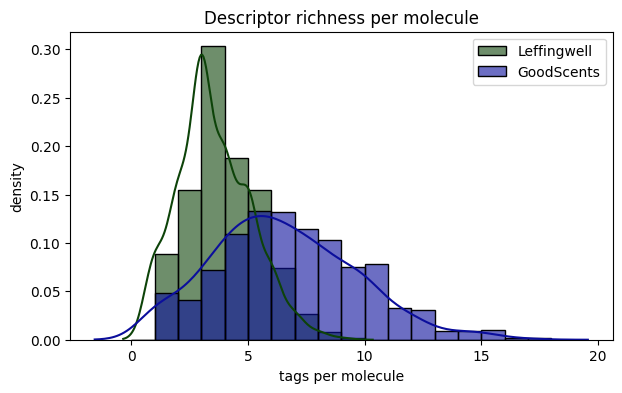

In [33]:
import seaborn as sns

print("tags/molecule  leffingwell:\n", df.loc[df.has_leff, "n_leff"].describe())
print("\ntags/molecule  goodscents:\n", df.loc[df.has_gs, "n_gs"].describe())

c_leff = "#0D4309" 
c_gs   = "#0B0E9C" 

fig, ax = plt.subplots(figsize=(7, 4))
bins = range(0, int(df[["n_leff", "n_gs"]].max().max()) + 2)
sns.histplot(df.loc[df.has_leff, "n_leff"], bins=bins, stat="density", alpha=.6, color=c_leff, label="Leffingwell", ax=ax)
sns.histplot(df.loc[df.has_gs, "n_gs"], bins=bins, stat="density", alpha=.6, color=c_gs, label="GoodScents", ax=ax)
sns.kdeplot(df.loc[df.has_leff, "n_leff"], color=c_leff, ax=ax)
sns.kdeplot(df.loc[df.has_gs, "n_gs"], color=c_gs, ax=ax)
ax.set_xlabel("tags per molecule")
ax.set_ylabel("density")
ax.set_title("Descriptor richness per molecule")
ax.legend()
plt.show()

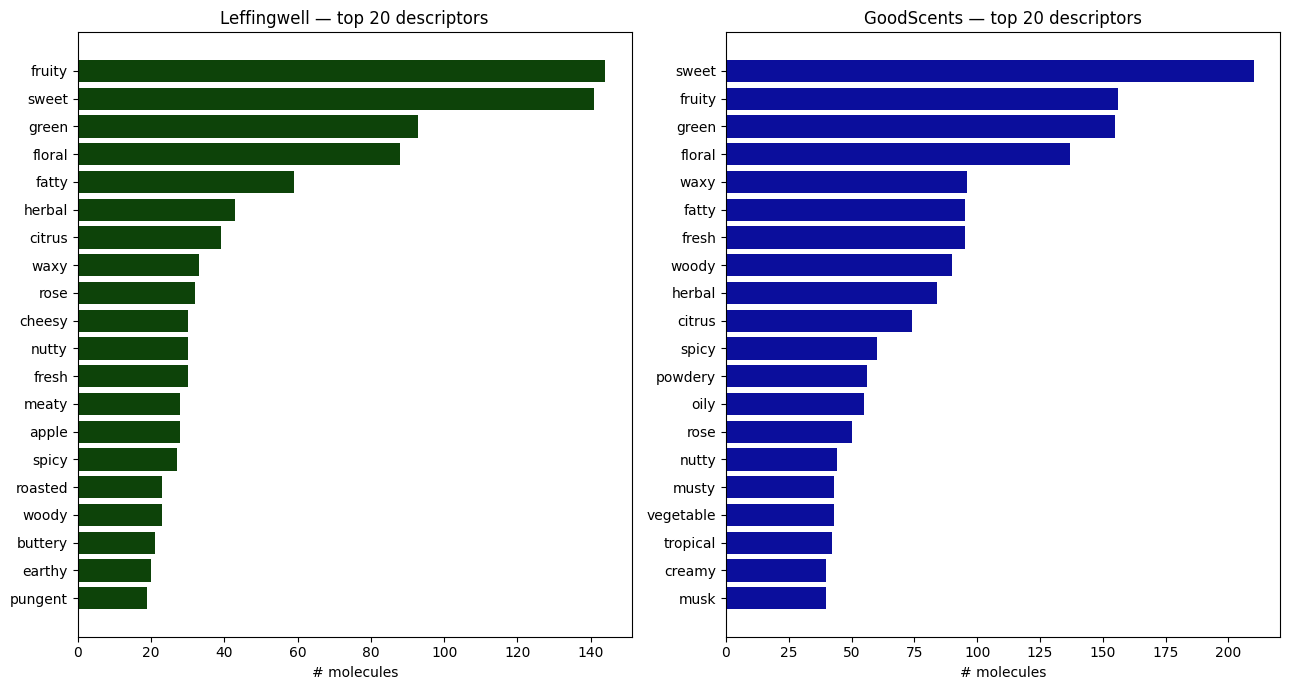

In [34]:
def top_bar(freq, title, ax, n=20, color=None):
    items = freq.most_common(n)[::-1]
    ax.barh([k for k, _ in items], [v for _, v in items], color=color)
    ax.set_title(title); ax.set_xlabel("# molecules")

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
top_bar(freq_leff, "Leffingwell — top 20 descriptors", axes[0], color=c_leff)
top_bar(freq_gs,   "GoodScents — top 20 descriptors",  axes[1], color=c_gs)
fig.tight_layout(); plt.show()

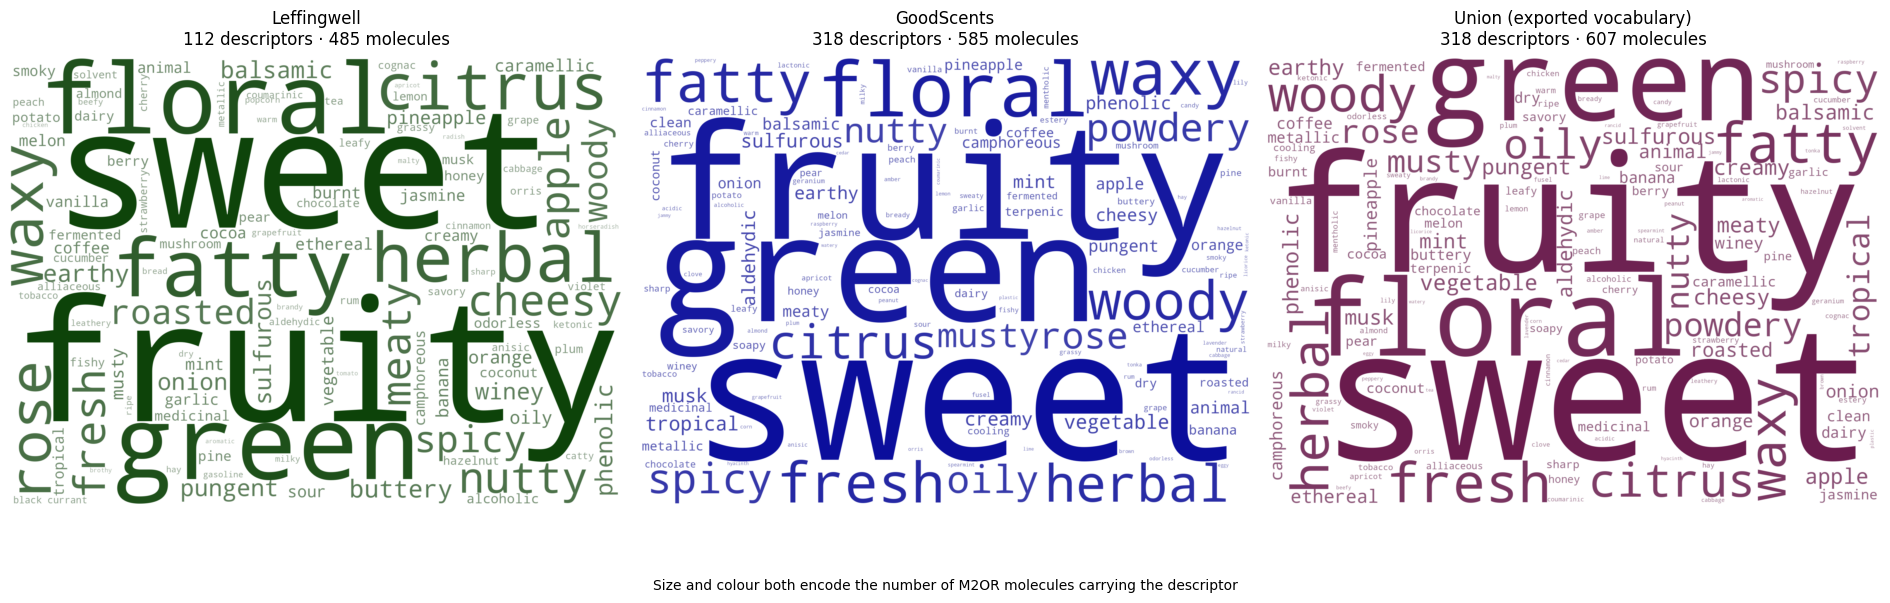

In [35]:
from wordcloud import WordCloud
from matplotlib.colors import LinearSegmentedColormap, to_hex

# A word cloud sizes terms by frequency but assigns colour at random, which reads as if the
# colour carried information. Here colour is a second encoding of the same quantity (pale =
# rare, saturated = common), the layout is seeded so the figure is reproducible, and a third
# panel shows the union vocabulary that the exported `Odors` column actually uses.
tags_union = [sorted(set(a) | set(b)) for a, b in zip(df.tags_leff, df.tags_gs)]
freq_all = Counter(t for tags in tags_union for t in tags)

def frequency_colour(freq, base):
    """Colour words along a pale -> base ramp keyed to log molecule count."""
    ramp = LinearSegmentedColormap.from_list("ramp", ["#dcdcdc", base])
    lo, hi = np.log1p(min(freq.values())), np.log1p(max(freq.values()))
    def colour(word, **kwargs):
        t = (np.log1p(freq[word]) - lo) / (hi - lo) if hi > lo else 1.0
        return to_hex(ramp(0.25 + 0.75 * t))
    return colour

panels = [
    (freq_leff, "Leffingwell", c_leff,   int(df.has_leff.sum())),
    (freq_gs,   "GoodScents",  c_gs,     int(df.has_gs.sum())),
    (freq_all,  "Union (exported vocabulary)", "#6A1B4D", len(df)),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))
for ax, (freq, title, base, n_mol) in zip(axes, panels):
    wc = WordCloud(
        width=1100, height=800, scale=2, background_color="white",
        collocations=False,            # keeps a multi-word tag as one token
        prefer_horizontal=0.92, relative_scaling=0.55,
        min_font_size=8, max_words=200, margin=3, random_state=0,
        color_func=frequency_colour(freq, base),
    ).generate_from_frequencies(freq)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{title}\n{len(freq)} descriptors · {n_mol} molecules", fontsize=12, pad=10)

fig.suptitle("Size and colour both encode the number of M2OR molecules carrying the descriptor",
             fontsize=10, y=0.04)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

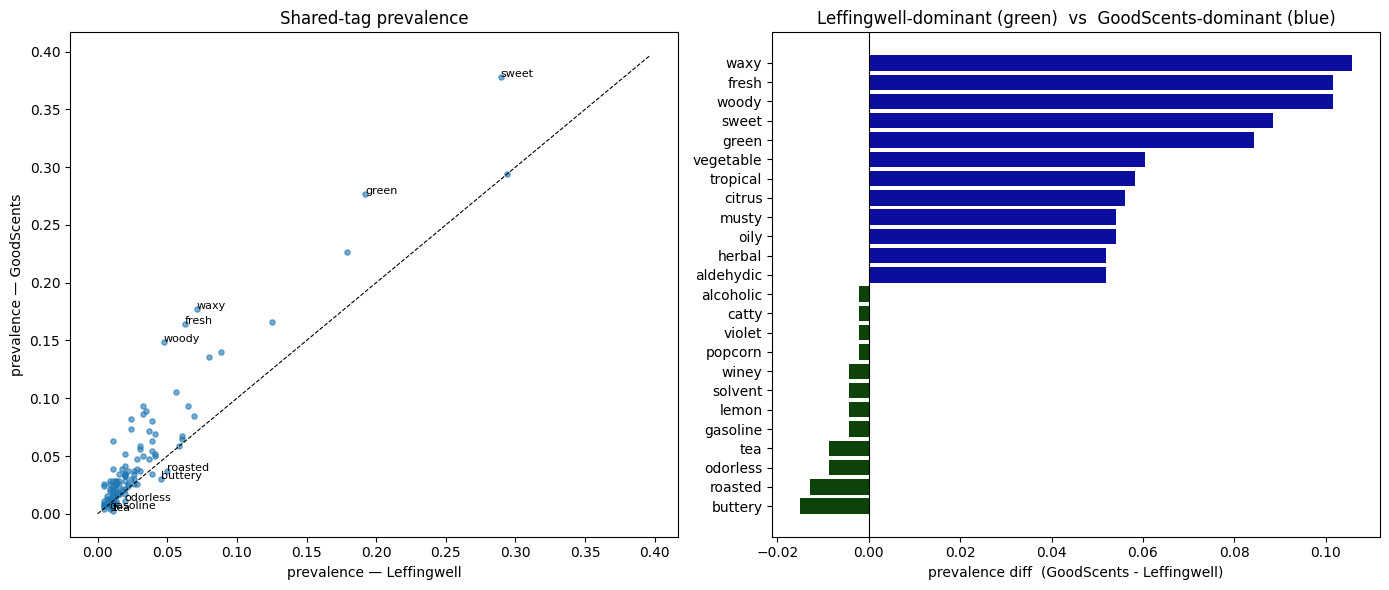

tags unique to Leffingwell: []

# tags unique to GoodScents: 206


In [36]:
both = df[df.coverage == "both"]
nB = len(both)

# prevalence = fraction of co-annotated molecules carrying the tag, per source
pl = Counter(t for tags in both.tags_leff for t in set(tags))
pg = Counter(t for tags in both.tags_gs   for t in set(tags))
shared = sorted(set(freq_leff) & set(freq_gs))

pv = pd.DataFrame({
    "tag": shared,
    "prev_leff": [pl[t] / nB for t in shared],
    "prev_gs":   [pg[t] / nB for t in shared],
})
pv["diff"] = pv.prev_gs - pv.prev_leff   # >0 = GoodScents-dominant, <0 = Leffingwell-dominant

# scatter: prevalence in one source vs the other
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
ax.scatter(pv.prev_leff, pv.prev_gs, s=14, alpha=.6)
lim = max(pv.prev_leff.max(), pv.prev_gs.max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=.8)
for _, r in pd.concat([pv.nlargest(5, "diff"), pv.nsmallest(5, "diff")]).iterrows():
    ax.annotate(r.tag, (r.prev_leff, r.prev_gs), fontsize=8)
ax.set_xlabel("prevalence — Leffingwell"); ax.set_ylabel("prevalence — GoodScents")
ax.set_title("Shared-tag prevalence")

# diverging bars: most over-represented on each side
top = pd.concat([pv.nlargest(12, "diff"), pv.nsmallest(12, "diff")]).sort_values("diff")
ax = axes[1]
ax.barh(top.tag, top["diff"], color=["#0D4309" if d < 0 else "#0B0E9C" for d in top["diff"]])
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("prevalence diff  (GoodScents - Leffingwell)")
ax.set_title("Leffingwell-dominant (green)  vs  GoodScents-dominant (blue)")
fig.tight_layout(); plt.show()

# descriptors that exist in one vocabulary but never the other (on this dataset)
print("tags unique to Leffingwell:", sorted(set(freq_leff) - set(freq_gs)))
print("\n# tags unique to GoodScents:", len(set(freq_gs) - set(freq_leff)))

In [37]:
import numpy as np
from collections import Counter

def cooccurrence(df, source="combined", min_count=5):
    """Tag×tag co-occurrence over molecules.
    source: 'combined' (union of both vocabularies per molecule), 'leff', or 'gs'.
    Returns: counts, jaccard, lift (DataFrames) and marginal tag frequencies (Series).
    """
    if source == "combined":
        tagsets = [sorted(set(a) | set(b)) for a, b in zip(df.tags_leff, df.tags_gs)]
    else:
        col = {"leff": "tags_leff", "gs": "tags_gs"}[source]
        tagsets = [sorted(set(x)) for x in df[col] if len(x) > 0]

    freq  = Counter(t for ts in tagsets for t in ts)
    vocab = sorted(t for t, c in freq.items() if c >= min_count)   # drop ultra-rare tags
    idx   = {t: i for i, t in enumerate(vocab)}

    # molecule × tag binary incidence
    B = np.zeros((len(tagsets), len(vocab)))
    for r, ts in enumerate(tagsets):
        for t in ts:
            if t in idx:
                B[r, idx[t]] = 1

    C = B.T @ B                      # co-occurrence counts; diagonal = marginal frequency
    n = B.shape[0]
    diag = np.diag(C).copy()
    union = diag[:, None] + diag[None, :] - C
    with np.errstate(divide="ignore", invalid="ignore"):
        J    = np.where(union > 0, C / union, 0.0)                          # Jaccard (0–1)
        lift = np.where((diag[:, None]*diag[None, :]) > 0,                  # >1 = above chance
                        C * n / (diag[:, None]*diag[None, :]), 0.0)

    f = lambda M: pd.DataFrame(M, index=vocab, columns=vocab)
    return f(C), f(J), f(lift), pd.Series(diag, index=vocab, name="marginal")

counts, jaccard, lift, marginal = cooccurrence(df, source="combined", min_count=5)
print("co-occurrence matrix:", counts.shape, "over", len(df), "molecules")

# strongest associations above chance (rank by lift, require a real co-count)
v = counts.index.tolist()
pairs = [(v[i], v[j], int(counts.iloc[i, j]), lift.iloc[i, j])
         for i in range(len(v)) for j in range(i+1, len(v))
         if counts.iloc[i, j] >= 8]
top_assoc = (pd.DataFrame(pairs, columns=["tag_a", "tag_b", "co_count", "lift"])
               .sort_values("lift", ascending=False).reset_index(drop=True))
top_assoc

co-occurrence matrix: (167, 167) over 607 molecules


,tag_a,tag_b,co_count,lift
0,alliaceous,garlic,13,25.957237
1,cooling,mentholic,8,21.972851
2,cucumber,melon,8,16.979021
3,peanut,roasted,9,16.861111
4,alliaceous,onion,14,16.597656
...,...,...,...,...
446,waxy,woody,9,0.563428
447,fruity,sulfurous,8,0.505097
448,cheesy,sweet,9,0.465015
449,sulfurous,sweet,9,0.444797


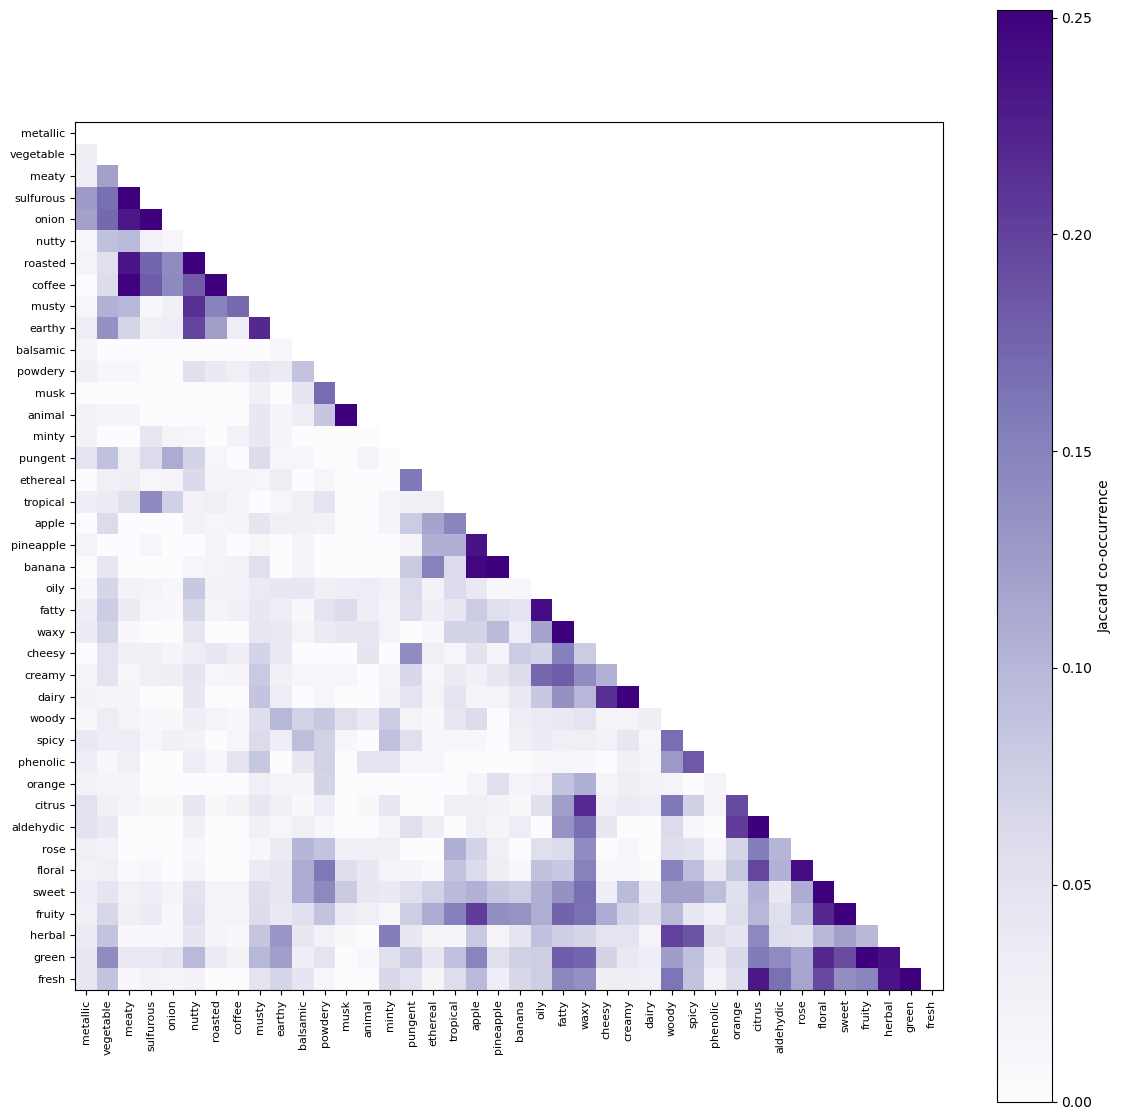

In [48]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

N = 40
top_tags = marginal.sort_values(ascending=False).head(N).index.tolist()
M = jaccard.loc[top_tags, top_tags].values

# hierarchical clustering on (1 - Jaccard) distance to order the matrix into blocks
D = 1 - M
np.fill_diagonal(D, 0.0)
D = (D + D.T) / 2                      # enforce symmetry for squareform
Z = linkage(squareform(D, checks=False), method="average")
order = leaves_list(Z)
labels = [top_tags[i] for i in order]
M_ord = M[np.ix_(order, order)]

# the matrix is symmetric and the diagonal is trivially 1, so half of it is redundant ink:
# blank everything on and above the diagonal and keep the lower triangle only
M_ord = np.where(np.tril(np.ones_like(M_ord), k=-1).astype(bool), M_ord, np.nan)
cmap = plt.get_cmap("Purples").copy()
cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(0.22 * N + 3, 0.22 * N + 2.5))
im = ax.imshow(M_ord, cmap=cmap, vmin=0, vmax=np.percentile(M[M > 0], 95))
ax.set_xticks(range(N)); ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticks(range(N)); ax.set_yticklabels(labels, fontsize=8)
#ax.set_title(f"Odor-tag co-occurrence (top {N} tags, Jaccard, hierarchically ordered)")
fig.colorbar(im, label="Jaccard co-occurrence")
fig.tight_layout(); plt.show()

### Do the two sources agree?

`Odors` unions two independent annotations of the same molecule. That is only defensible if
they broadly agree — measured per molecule (Jaccard) and per descriptor (Cohen's kappa).

molecules described by both sources: 463
per-molecule Jaccard  median 0.250  mean 0.291  | exactly 0 overlap: 29 molecules

shared descriptors scored: 102   median kappa 0.429


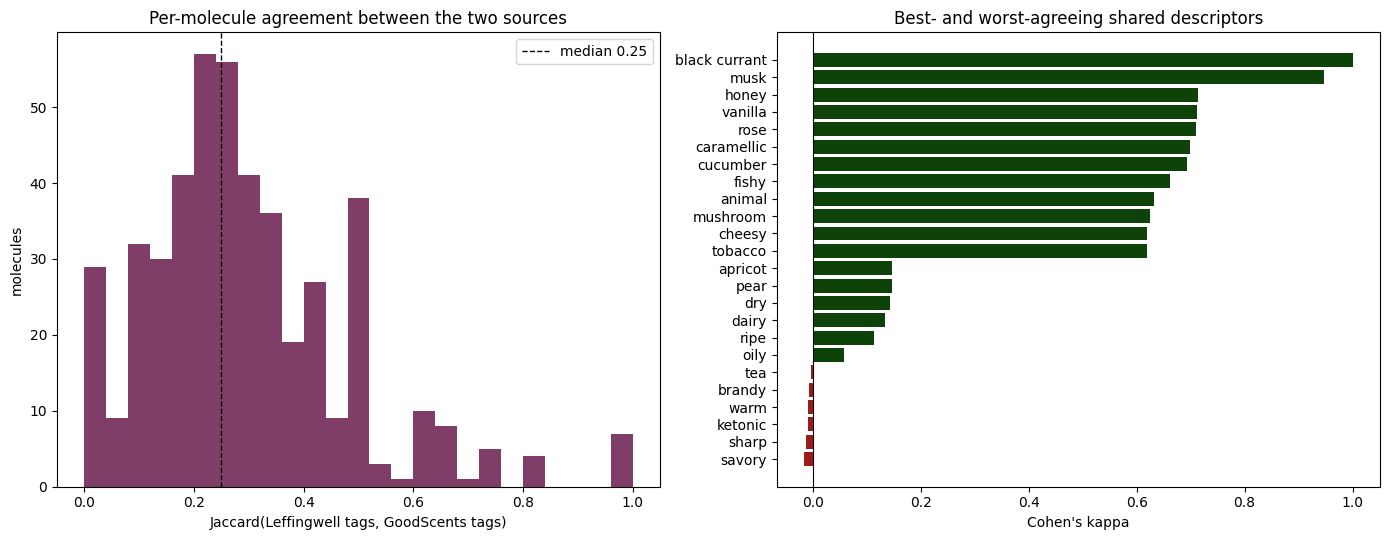


lowest agreement (one source uses the term, the other does not):
    tag  n_leff  n_gs     kappa
   ripe       4    12  0.113512
   oily      16    41  0.058455
    tea       5     1 -0.003613
 brandy       2     5 -0.006209
   warm       3     7 -0.009154
ketonic       4     5 -0.009692
  sharp       4    13 -0.013390
 savory       5    13 -0.015846


In [39]:
# The pipeline unions two independent annotations, which is only defensible if they agree.
# For the molecules described by both sources, measure overlap per molecule (Jaccard) and
# per descriptor (Cohen's kappa, restricted to the shared vocabulary).
from sklearn.metrics import cohen_kappa_score

both_df = df[df.coverage == "both"]
jac = np.array([len(set(a) & set(b)) / len(set(a) | set(b))
                for a, b in zip(both_df.tags_leff, both_df.tags_gs)])
print(f"molecules described by both sources: {len(both_df)}")
print(f"per-molecule Jaccard  median {np.median(jac):.3f}  mean {jac.mean():.3f}  "
      f"| exactly 0 overlap: {(jac == 0).sum()} molecules")

shared_vocab = sorted(set(freq_leff) & set(freq_gs))
rows = []
for tag in shared_vocab:
    a = np.array([tag in t for t in both_df.tags_leff])
    b = np.array([tag in t for t in both_df.tags_gs])
    if a.sum() < 5 and b.sum() < 5:
        continue
    rows.append(dict(tag=tag, n_leff=int(a.sum()), n_gs=int(b.sum()),
                     kappa=cohen_kappa_score(a, b)))
kappa = pd.DataFrame(rows).sort_values("kappa", ascending=False).reset_index(drop=True)
print(f"\nshared descriptors scored: {len(kappa)}   median kappa {kappa.kappa.median():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].hist(jac, bins=25, color="#6A1B4D", alpha=.85)
axes[0].axvline(np.median(jac), color="k", ls="--", lw=1,
                label=f"median {np.median(jac):.2f}")
axes[0].set_xlabel("Jaccard(Leffingwell tags, GoodScents tags)")
axes[0].set_ylabel("molecules"); axes[0].legend()
axes[0].set_title("Per-molecule agreement between the two sources")

top = pd.concat([kappa.head(12), kappa.tail(12)])
axes[1].barh(top.tag, top.kappa,
             color=["#0D4309" if k > 0 else "#9C1B1B" for k in top.kappa])
axes[1].axvline(0, color="k", lw=.8)
axes[1].set_xlabel("Cohen's kappa"); axes[1].invert_yaxis()
axes[1].set_title("Best- and worst-agreeing shared descriptors")
fig.tight_layout(); plt.show()

print("\nlowest agreement (one source uses the term, the other does not):")
print(kappa.tail(8).to_string(index=False))

### Is it correct to keep both sources for the same molecule?

Union is the right operator for *presence*: neither source's zero means "assessed and
rejected", so an intersection would silently delete true descriptors. What union does buy is
a covariate — tag-set size becomes partly a function of database coverage.

In [40]:
from scipy.stats import kruskal

# Unioning two sources is only free if it does not smuggle a covariate into the data. It
# does: a molecule's tag count is largely a function of how many sources describe it, not of
# how many things it smells of. That is a property of the databases, not of the chemistry.
n_tags = df.tags_leff.combine(df.tags_gs, lambda a, b: len(set(a) | set(b)))
print("tags per molecule by source coverage:")
print(pd.DataFrame({"n_tags": n_tags, "coverage": df.coverage})
        .groupby("coverage")["n_tags"].agg(["size", "median", "mean"]).round(2).to_string())
print("Kruskal-Wallis p = %.2e" % kruskal(
    *[g.values for _, g in n_tags.groupby(df.coverage)]).pvalue)

both_df = df[df.coverage == "both"]
print("\non the %d molecules both sources describe:" % len(both_df))
print("  median tags, Leffingwell alone : %d" % both_df.n_leff.median())
print("  median tags, GoodScents alone  : %d" % both_df.n_gs.median())
print("  median tags, union             : %d" % n_tags[df.coverage == "both"].median())
print("  median GoodScents adds over Leffingwell: %.0f" % np.median(
    [len(set(g) - set(l)) for l, g in zip(both_df.tags_leff, both_df.tags_gs)]))
print("  median Leffingwell adds over GoodScents: %.0f" % np.median(
    [len(set(l) - set(g)) for l, g in zip(both_df.tags_leff, both_df.tags_gs)]))

# The consequence: presence/absence questions are safe, anything that reads tag-set *size*
# is not. Any such analysis should either stratify on `coverage` or restrict to `both`.

tags per molecule by source coverage:
           size  median  mean
coverage                     
both        463     8.0  8.22
gs_only     122     5.0  5.17
leff_only    22     3.0  3.32
Kruskal-Wallis p = 4.52e-28

on the 463 molecules both sources describe:
  median tags, Leffingwell alone : 3
  median tags, GoodScents alone  : 7
  median tags, union             : 8
  median GoodScents adds over Leffingwell: 4
  median Leffingwell adds over GoodScents: 1


### Does the annotation behave chemically?

Each molecule is reduced to a set of functional groups and every (group, descriptor) pair is
tested with Fisher's exact test under BH correction. Recovering the textbook associations is
a sanity check on the whole merge.

In [41]:
# Recovering the textbook associations (thiol -> sulfurous, ester -> fruity, terpene -> pine)
# is the sanity check; anything unexpected is worth a second look.
from statsmodels.stats.multitest import multipletests

GROUPS = {
    "thiol":        "[#16;H1X2]",
    "sulfide":      "[#16X2]([#6])[#6]",
    "ester":        "[CX3](=O)[OX2H0][#6]",
    "carboxyl":     "[CX3](=O)[OX2H1]",
    "aldehyde":     "[CX3H1](=O)[#6]",
    "ketone":       "[#6][CX3](=O)[#6]",
    "alcohol":      "[OX2H][CX4]",
    "phenol":       "[OX2H]c",
    "aromatic":     "c1ccccc1",
    "amine":        "[NX3;H2,H1,H0;!$(NC=O)]",
    "nitrile":      "[NX1]#[CX2]",
    "lactone":      "[CX3](=O)[OX2H0][#6;R]",
    "ether":        "[OD2]([#6])[#6]",
    "terpene-like": "[CX4]([CH3])([CH3])",
    "halogen":      "[F,Cl,Br,I]",
}
patterns = {k: Chem.MolFromSmarts(v) for k, v in GROUPS.items()}

chem = df.copy()
chem["mol"] = chem["SMILES"].map(Chem.MolFromSmiles)
chem = chem[chem["mol"].notna()]
chem["tags_all"] = [sorted(set(a) | set(b)) for a, b in zip(chem.tags_leff, chem.tags_gs)]
for name, patt in patterns.items():
    chem[name] = chem["mol"].map(lambda m, p=patt: m.HasSubstructMatch(p))

tag_counts = Counter(t for ts in chem.tags_all for t in ts)
test_tags = [t for t, c in tag_counts.items() if c >= 10]
print(f"{len(chem)} molecules x {len(GROUPS)} groups x {len(test_tags)} descriptors "
      f"(>= 10 molecules)")

rows = []
for name in GROUPS:
    has = chem[name].values
    if has.sum() < 5:
        continue
    for tag in test_tags:
        tagged = np.array([tag in ts for ts in chem.tags_all])
        table = [[int((has & tagged).sum()),  int((has & ~tagged).sum())],
                 [int((~has & tagged).sum()), int((~has & ~tagged).sum())]]
        if table[0][0] < 3:
            continue
        odds, p = fisher_exact(table)   # two-sided: depletions are informative too
        rows.append(dict(group=name, tag=tag, n=table[0][0], odds_ratio=odds, p=p))

enrich = pd.DataFrame(rows)
enrich["q"] = multipletests(enrich["p"], method="fdr_bh")[1]
enrich = enrich.sort_values("q").reset_index(drop=True)
sig = enrich[enrich.q < 0.05]
print(f"significant (group, descriptor) associations at FDR 5%: {len(sig)}\n")
print(sig.sort_values("odds_ratio", ascending=False).head(20).to_string(index=False))

607 molecules x 15 groups x 111 descriptors (>= 10 molecules)


significant (group, descriptor) associations at FDR 5%: 193

       group        tag  n  odds_ratio            p            q
    aromatic    vanilla 17         inf 9.880935e-12 3.550961e-10
       thiol  sulfurous 21  470.400000 3.795762e-25 2.182563e-22
      phenol      smoky 13  137.944444 4.947314e-16 4.063865e-14
    carboxyl   odorless 12  101.818182 5.032109e-13 2.411219e-11
      phenol   phenolic 23   84.282895 1.044406e-23 2.001778e-21
     sulfide  sulfurous 13   73.272727 2.268371e-13 1.185739e-11
    carboxyl       sour 16   61.462069 7.805831e-16 5.610441e-14
      ketone    ketonic 11   58.627660 2.713170e-08 4.457350e-07
    aldehyde  aldehydic 31   44.980392 2.360585e-23 3.393341e-21
       ester    apricot 12   40.029197 3.468518e-07 4.335648e-06
       ester       pear 21   37.406250 7.935034e-12 3.041763e-10
     nitrile      lemon  3   35.340000 4.056300e-04 2.159604e-03
      phenol  medicinal 12   32.440191 2.925825e-11 9.346386e-10
    aromatic      clove  9   

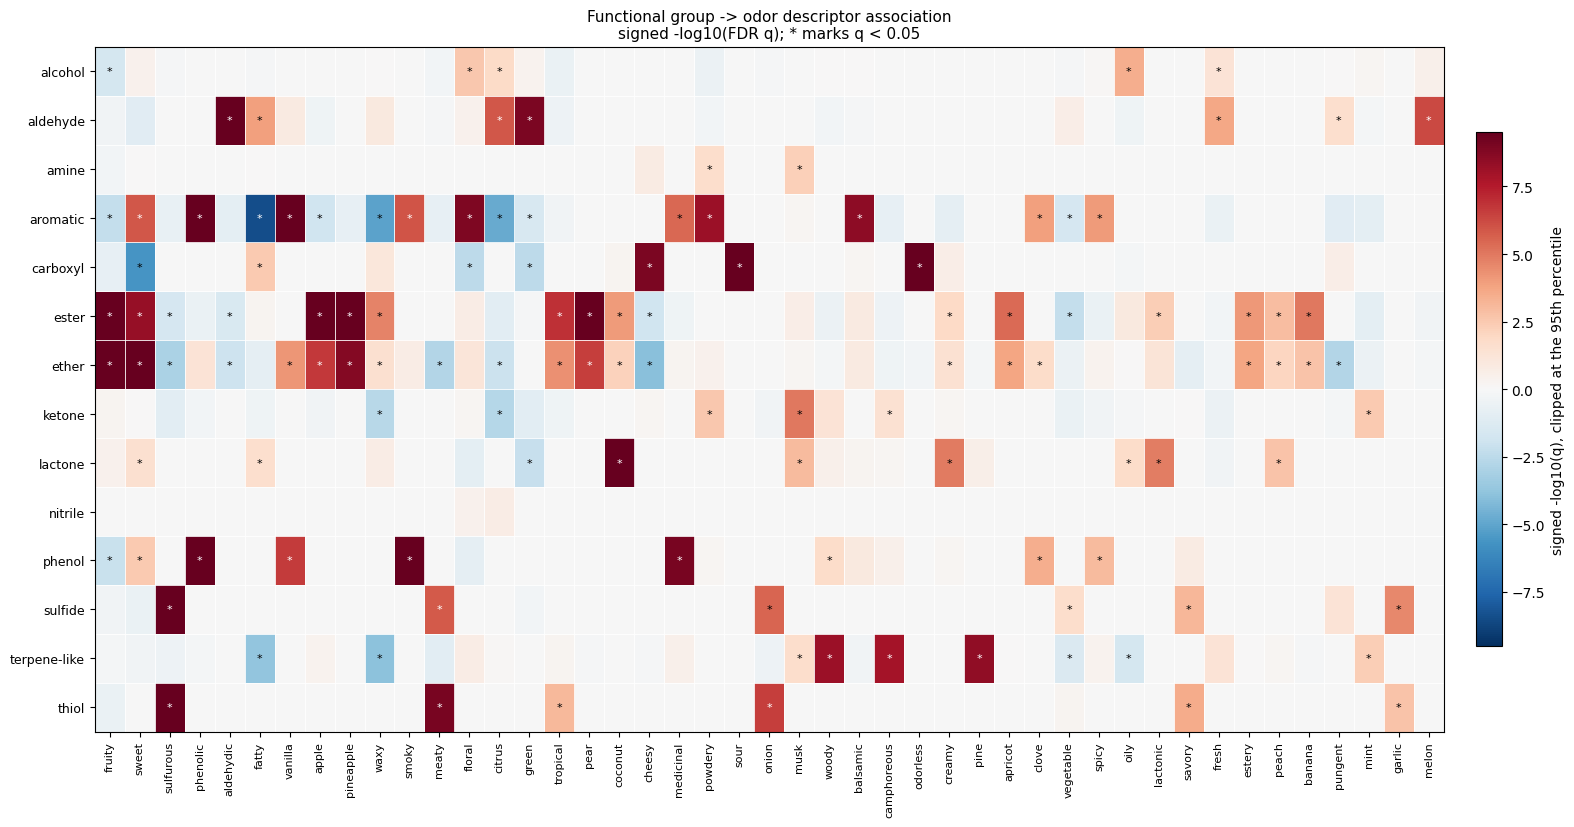

In [42]:
# The same tests laid out as a group x descriptor map, so the blocks are visible at a glance.
# Red = the descriptor is over-represented among molecules carrying the group, blue = under.
# Columns are the 45 descriptors with the strongest evidence, ordered by total signal.
enrich["score"] = -np.log10(enrich["q"]) * np.sign(np.log2(enrich["odds_ratio"].clip(1e-3)))
mat = enrich.pivot_table(index="group", columns="tag", values="score").fillna(0)
mat = mat[mat.abs().sum().sort_values(ascending=False).head(45).index]

fig, ax = plt.subplots(figsize=(0.32 * mat.shape[1] + 3, 0.42 * mat.shape[0] + 2.5))
vmax = np.percentile(np.abs(mat.values[mat.values != 0]), 95)   # clipped: thiol->sulfurous dwarfs everything
im = ax.imshow(mat.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(mat.columns, rotation=90, fontsize=8)
ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(mat.index, fontsize=9)
ax.set_xticks(np.arange(-.5, mat.shape[1]), minor=True)
ax.set_yticks(np.arange(-.5, mat.shape[0]), minor=True)
ax.grid(which="minor", color="w", lw=.6); ax.tick_params(which="minor", length=0)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        if abs(mat.values[i, j]) > -np.log10(0.05):
            ax.text(j, i, "*", ha="center", va="center", fontsize=8,
                    color="w" if abs(mat.values[i, j]) > .6 * vmax else "k")
ax.set_title("Functional group -> odor descriptor association\n"
             "signed -log10(FDR q); * marks q < 0.05", fontsize=11)
fig.colorbar(im, ax=ax, shrink=.75, pad=.02, label="signed -log10(q), clipped at the 95th percentile")
fig.tight_layout(); plt.show()

### Percept versus receptive breadth

The reason for annotating M2OR at all: relating the descriptor a molecule carries to how many
olfactory receptors it activates.

263 molecules screened against >= 10 ORs (median 49 ORs each)


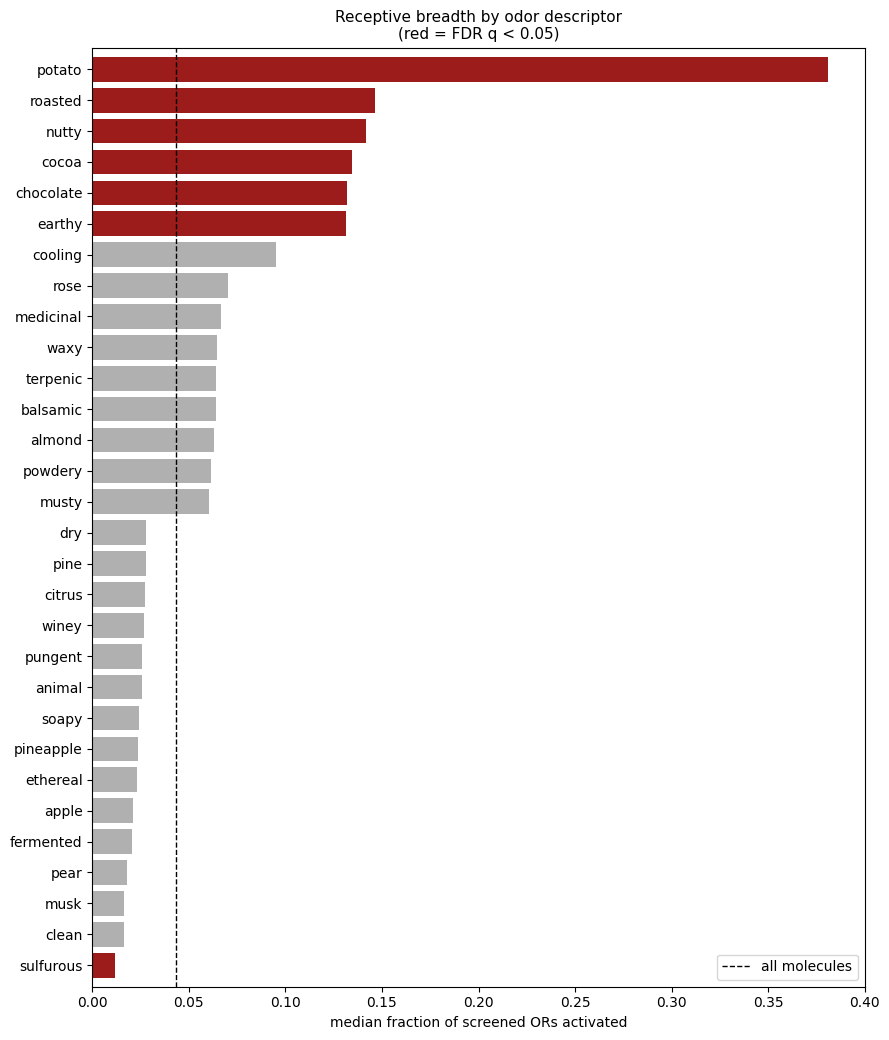

      tag  n  median_hit_rate  background        p        q
   potato 15         0.380952    0.040816 0.000020 0.000569
  roasted 20         0.146498    0.040816 0.000297 0.005543
    nutty 32         0.141546    0.040632 0.000008 0.000452
    cocoa 14         0.134566    0.041667 0.002551 0.023807
chocolate 15         0.132075    0.042553 0.005722 0.045774
   earthy 30         0.131612    0.040816 0.000668 0.009353
sulfurous 14         0.011497    0.045113 0.001160 0.012987


In [43]:
# The point of annotating M2OR is to relate percept to receptor activation. Receptive
# breadth = the number of distinct ORs a molecule activates in M2OR; the question is whether
# any descriptor class is systematically broad or narrow.
mono = m2or[m2or["Mixture"] != "mixture"]
breadth = (mono[mono["Responsive"] == 1]
           .groupby("SMILES")["UniProt ID"].nunique().rename("n_or_activated"))
screened = mono.groupby("SMILES")["UniProt ID"].nunique().rename("n_or_screened")

link = (chem.set_index("SMILES")[["tags_all", "coverage"]]
            .join(screened).join(breadth)
            .assign(n_or_activated=lambda d: d.n_or_activated.fillna(0)))
# only molecules screened against enough receptors for breadth to mean anything
link = link[link.n_or_screened >= 10]
link["hit_rate"] = link.n_or_activated / link.n_or_screened
print(f"{len(link)} molecules screened against >= 10 ORs "
      f"(median {int(link.n_or_screened.median())} ORs each)")

rows = []
for tag, c in Counter(t for ts in link.tags_all for t in ts).items():
    if c < 10:
        continue
    has = np.array([tag in ts for ts in link.tags_all])
    u = mannwhitneyu(link.hit_rate[has], link.hit_rate[~has])
    rows.append(dict(tag=tag, n=int(has.sum()),
                     median_hit_rate=link.hit_rate[has].median(),
                     background=link.hit_rate[~has].median(), p=u.pvalue))
breadth_tbl = pd.DataFrame(rows)
breadth_tbl["q"] = multipletests(breadth_tbl["p"], method="fdr_bh")[1]
breadth_tbl = breadth_tbl.sort_values("median_hit_rate", ascending=False).reset_index(drop=True)

top = pd.concat([breadth_tbl.head(15), breadth_tbl.tail(15)])
fig, ax = plt.subplots(figsize=(9, 0.30 * len(top) + 1.5))
colours = ["#9C1B1B" if q < .05 else "#b0b0b0" for q in top.q]
ax.barh(top.tag, top.median_hit_rate, color=colours)
ax.axvline(link.hit_rate.median(), color="k", ls="--", lw=1, label="all molecules")
ax.invert_yaxis(); ax.margins(y=0.01); ax.set_xlabel("median fraction of screened ORs activated")
ax.set_title("Receptive breadth by odor descriptor\n(red = FDR q < 0.05)", fontsize=11)
ax.legend(); fig.tight_layout(); plt.show()

print(breadth_tbl[breadth_tbl.q < 0.05].to_string(index=False))

### Does the coverage covariate reach any result?

The receptive-breadth associations, re-tested on the `both`-coverage molecules alone. An
association driven by unequal annotation depth should evaporate here.

In [44]:
# Does the confound actually reach a result? Re-run the receptive-breadth test on the
# `both`-coverage molecules only: if an association is an artefact of unequal annotation
# depth, it should evaporate here.
robust = []
for tag in breadth_tbl.loc[breadth_tbl.q < 0.05, "tag"]:
    row = {"tag": tag}
    for label, sub in [("all", link), ("both-coverage only", link[link.coverage == "both"])]:
        has = np.array([tag in ts for ts in sub.tags_all])
        row[f"n ({label})"] = int(has.sum())
        row[f"median hit ({label})"] = sub.hit_rate[has].median() if has.sum() else np.nan
        row[f"p ({label})"] = (mannwhitneyu(sub.hit_rate[has], sub.hit_rate[~has]).pvalue
                               if has.sum() >= 5 else np.nan)
    robust.append(row)
print(pd.DataFrame(robust).round(4).to_string(index=False))
print("\ncoverage is itself unrelated to receptive breadth:")
print(link.groupby("coverage")["hit_rate"].agg(["size", "median"]).round(3).to_string())
print("Kruskal-Wallis p = %.3f" % kruskal(
    *[g.hit_rate.values for _, g in link.groupby("coverage") if len(g) > 2]).pvalue)

      tag  n (all)  median hit (all)  p (all)  n (both-coverage only)  median hit (both-coverage only)  p (both-coverage only)
   potato       15            0.3810   0.0000                      14                           0.2642                  0.0001
  roasted       20            0.1465   0.0003                      18                           0.1465                  0.0017
    nutty       32            0.1415   0.0000                      31                           0.1379                  0.0000
    cocoa       14            0.1346   0.0026                      14                           0.1346                  0.0026
chocolate       15            0.1321   0.0057                      15                           0.1321                  0.0063
   earthy       30            0.1316   0.0007                      28                           0.1316                  0.0014
sulfurous       14            0.0115   0.0012                      13                           0.0178         